In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
!pip install ydata-profiling
from ydata_profiling import ProfileReport
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from mpl_toolkits.mplot3d import Axes3D
from sklearn.svm import OneClassSVM
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
!pip install hmmlearn
from hmmlearn import hmm
from sklearn.metrics import silhouette_score, calinski_harabasz_score

In [ ]:
df = pd.read_csv('/content/Games.csv')

In [ ]:
df

,Liste cheat white,Liste cheat black,Game,Elo White,Elo Black,Score
0,00000000001111101010111010100110000001001111,0000000000111001000000001100100000000111000,1. d4 e6 2. c4 d5 3. Nc3 Be7 4. Nf3 Nf6 5. Bf4...,1001,-1,1/2-1/2
1,0000000000000010111101100000100111000111101111001,0000000000110111110111111111111111111011111111111,1. d4 c5 2. c4 cxd4 3. Qxd4 Nc6 4. Qd1 e6 5. N...,1001,-1,1/2-1/2
2,0000000000111001110111100111111110101011110111...,0000000000111111100001111111111111111111010101...,1. e4 e5 2. d4 exd4 3. Qxd4 Nc6 4. Qd3 b6 5. B...,1001,-1,1/2-1/2
3,000000000011111101111111110110101111111,00000000000001101001000011100111100110,1. e4 e5 2. Nf3 Nf6 3. Nc3 Bc5 4. Bc4 d6 5. O-...,1002,-1,1/2-1/2
4,0000000000001000111010111101001010011010011011...,0000000000000000010000001110011010100010001100...,1. d4 d5 2. c4 Nf6 3. Nc3 e6 4. Bg5 Be7 5. e3 ...,1002,-1,1/2-1/2
...,...,...,...,...,...,...
48928,00000000000000000000000000000,00000000001001000000110010111,1. e4 e5 2. Qh5 Qe7 3. Bc4 Nf6 4. Qf3 d6 5. h3...,1841,1806,0-1
48929,0000000000000000000000000000000000000000,0000000000110011011110011111101110101001,1. c4 d5 2. c5 c6 3. b4 Bf5 4. d3 e6 5. Bf4 Nd...,1562,1561,0-1
48930,0000000000000000000000000000000000000000000000...,0000000000100110100100000100001000100100100110...,1. e4 e5 2. Bc4 Nf6 3. Nf3 d6 4. Ng5 Be6 5. Bx...,1476,1420,1-0
48931,0000000000000000000000000000000,000000000010000001000000010100,1. d4 Nf6 2. c4 g6 3. Nc3 e6 4. Nf3 Bg7 5. e4 ...,1745,1536,1-0


In [ ]:
df[['score_1', 'score_2']] = df['Score'].str.split('-', expand=True)

df['result'] = df.apply(lambda row: 0 if row['score_1'] == '1' else (1 if row['score_2'] == '1' else 2), axis=1)

df = df.drop(columns=['score_1', 'score_2'])
df

,Liste cheat white,Liste cheat black,Game,Elo White,Elo Black,Score,result
0,00000000001111101010111010100110000001001111,0000000000111001000000001100100000000111000,1. d4 e6 2. c4 d5 3. Nc3 Be7 4. Nf3 Nf6 5. Bf4...,1001,-1,1/2-1/2,2
1,0000000000000010111101100000100111000111101111001,0000000000110111110111111111111111111011111111111,1. d4 c5 2. c4 cxd4 3. Qxd4 Nc6 4. Qd1 e6 5. N...,1001,-1,1/2-1/2,2
2,0000000000111001110111100111111110101011110111...,0000000000111111100001111111111111111111010101...,1. e4 e5 2. d4 exd4 3. Qxd4 Nc6 4. Qd3 b6 5. B...,1001,-1,1/2-1/2,2
3,000000000011111101111111110110101111111,00000000000001101001000011100111100110,1. e4 e5 2. Nf3 Nf6 3. Nc3 Bc5 4. Bc4 d6 5. O-...,1002,-1,1/2-1/2,2
4,0000000000001000111010111101001010011010011011...,0000000000000000010000001110011010100010001100...,1. d4 d5 2. c4 Nf6 3. Nc3 e6 4. Bg5 Be7 5. e3 ...,1002,-1,1/2-1/2,2
...,...,...,...,...,...,...,...
48928,00000000000000000000000000000,00000000001001000000110010111,1. e4 e5 2. Qh5 Qe7 3. Bc4 Nf6 4. Qf3 d6 5. h3...,1841,1806,0-1,1
48929,0000000000000000000000000000000000000000,0000000000110011011110011111101110101001,1. c4 d5 2. c5 c6 3. b4 Bf5 4. d3 e6 5. Bf4 Nd...,1562,1561,0-1,1
48930,0000000000000000000000000000000000000000000000...,0000000000100110100100000100001000100100100110...,1. e4 e5 2. Bc4 Nf6 3. Nf3 d6 4. Ng5 Be6 5. Bx...,1476,1420,1-0,0
48931,0000000000000000000000000000000,000000000010000001000000010100,1. d4 Nf6 2. c4 g6 3. Nc3 e6 4. Nf3 Bg7 5. e4 ...,1745,1536,1-0,0


In [ ]:
def count_ones(series):
    return series.count('1')

df['Liste cheat white'] = df['Liste cheat white'].apply(count_ones)

In [ ]:
df['Liste cheat black'] = df['Liste cheat black'].apply(count_ones)
df

,Liste cheat white,Liste cheat black,Game,Elo White,Elo Black,Score,result
0,19,10,1. d4 e6 2. c4 d5 3. Nc3 Be7 4. Nf3 Nf6 5. Bf4...,1001,-1,1/2-1/2,2
1,20,36,1. d4 c5 2. c4 cxd4 3. Qxd4 Nc6 4. Qd1 e6 5. N...,1001,-1,1/2-1/2,2
2,43,41,1. e4 e5 2. d4 exd4 3. Qxd4 Nc6 4. Qd3 b6 5. B...,1001,-1,1/2-1/2,2
3,25,13,1. e4 e5 2. Nf3 Nf6 3. Nc3 Bc5 4. Bc4 d6 5. O-...,1002,-1,1/2-1/2,2
4,34,15,1. d4 d5 2. c4 Nf6 3. Nc3 e6 4. Bg5 Be7 5. e3 ...,1002,-1,1/2-1/2,2
...,...,...,...,...,...,...,...
48928,0,8,1. e4 e5 2. Qh5 Qe7 3. Bc4 Nf6 4. Qf3 d6 5. h3...,1841,1806,0-1,1
48929,0,20,1. c4 d5 2. c5 c6 3. b4 Bf5 4. d3 e6 5. Bf4 Nd...,1562,1561,0-1,1
48930,0,12,1. e4 e5 2. Bc4 Nf6 3. Nf3 d6 4. Ng5 Be6 5. Bx...,1476,1420,1-0,0
48931,0,4,1. d4 Nf6 2. c4 g6 3. Nc3 e6 4. Nf3 Bg7 5. e4 ...,1745,1536,1-0,0


In [ ]:
# Function to modify the 'Elo Black' column
def modify_elo_black(row):
    if row['Elo Black'] == -1:
        return row['Elo White'] - 1
    else:
        return row['Elo Black']

# Apply the function to each row
df['Elo Black'] = df.apply(modify_elo_black, axis=1)

In [ ]:
# Function to modify the 'Elo White' column
def modify_elo_white(row):
    if row['Elo White'] == -1:
        return row['Elo Black'] - 1
    else:
        return row['Elo White']

# Apply the function to each row
df['Elo White'] = df.apply(modify_elo_white, axis=1)

In [ ]:
df

,Liste cheat white,Liste cheat black,Game,Elo White,Elo Black,Score,result
0,19,10,1. d4 e6 2. c4 d5 3. Nc3 Be7 4. Nf3 Nf6 5. Bf4...,1001,1000,1/2-1/2,2
1,20,36,1. d4 c5 2. c4 cxd4 3. Qxd4 Nc6 4. Qd1 e6 5. N...,1001,1000,1/2-1/2,2
2,43,41,1. e4 e5 2. d4 exd4 3. Qxd4 Nc6 4. Qd3 b6 5. B...,1001,1000,1/2-1/2,2
3,25,13,1. e4 e5 2. Nf3 Nf6 3. Nc3 Bc5 4. Bc4 d6 5. O-...,1002,1001,1/2-1/2,2
4,34,15,1. d4 d5 2. c4 Nf6 3. Nc3 e6 4. Bg5 Be7 5. e3 ...,1002,1001,1/2-1/2,2
...,...,...,...,...,...,...,...
48928,0,8,1. e4 e5 2. Qh5 Qe7 3. Bc4 Nf6 4. Qf3 d6 5. h3...,1841,1806,0-1,1
48929,0,20,1. c4 d5 2. c5 c6 3. b4 Bf5 4. d3 e6 5. Bf4 Nd...,1562,1561,0-1,1
48930,0,12,1. e4 e5 2. Bc4 Nf6 3. Nf3 d6 4. Ng5 Be6 5. Bx...,1476,1420,1-0,0
48931,0,4,1. d4 Nf6 2. c4 g6 3. Nc3 e6 4. Nf3 Bg7 5. e4 ...,1745,1536,1-0,0


In [ ]:
df.rename(columns={'Liste cheat white': 'Flagged white move', 'Liste cheat black': 'Flagged black move'}, inplace=True)

In [ ]:
df.drop('Score',inplace=True,axis=1)

In [ ]:
df.drop('Game',inplace=True,axis=1)

In [ ]:
df_cleaned = df

In [ ]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48933 entries, 0 to 48932
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Flagged white move  48933 non-null  int64
 1   Flagged black move  48933 non-null  int64
 2   Elo White           48933 non-null  int64
 3   Elo Black           48933 non-null  int64
 4   result              48933 non-null  int64
dtypes: int64(5)
memory usage: 1.9 MB


In [ ]:
df_cleaned.describe()

,Flagged white move,Flagged black move,Elo White,Elo Black,result
count,48933.000000,48933.000000,48933.000000,48933.000000,48933.000000
mean,7.264525,8.645781,1720.035375,1731.437087,0.771913
std,12.066842,12.587222,228.545259,220.046312,0.718508
min,0.000000,0.000000,593.000000,1000.000000,0.000000
25%,0.000000,0.000000,1583.000000,1604.000000,0.000000
50%,0.000000,1.000000,1762.000000,1774.000000,1.000000
75%,12.000000,14.000000,1890.000000,1897.000000,1.000000
max,165.000000,166.000000,2616.000000,2615.000000,2.000000


In [ ]:
df_cleaned.isna().sum()

,0
Flagged white move,0
Flagged black move,0
Elo White,0
Elo Black,0
result,0


In [ ]:
!pip install ydata-profiling

In [ ]:
profile = ProfileReport(df,title = 'ChessCheating')
profile.to_notebook_iframe()
profile.to_file("books_data.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
y = df['result']
x = df.drop('result',axis=1)

In [ ]:
print(x.shape)
print(y.shape)

(48933, 4)
(48933,)


In [ ]:
clf = IsolationForest(contamination='auto', n_estimators=100, max_samples=900, max_features=1.0, bootstrap=True, n_jobs=None, random_state=None, verbose=0, warm_start=False)
clf.fit(df)

IsolationForest(bootstrap=True, max_samples=900)

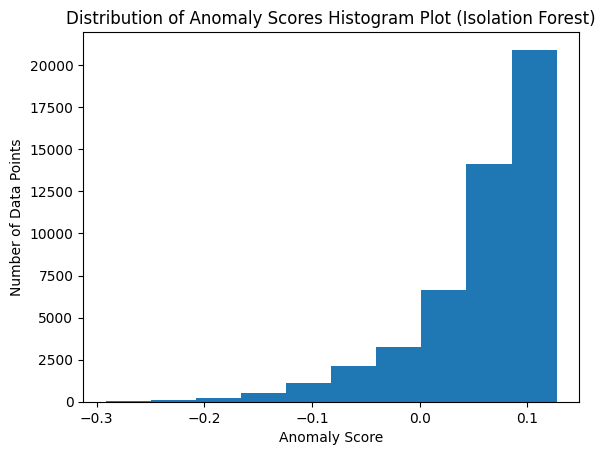

In [ ]:
anomaly_scores = clf.decision_function(df)

# Analyze the distribution of anomaly scores
# Higher scores might indicate potential anomalies
plt.hist(anomaly_scores)
plt.xlabel("Anomaly Score")
plt.ylabel("Number of Data Points")
plt.title("Distribution of Anomaly Scores Histogram Plot (Isolation Forest)")
plt.show()

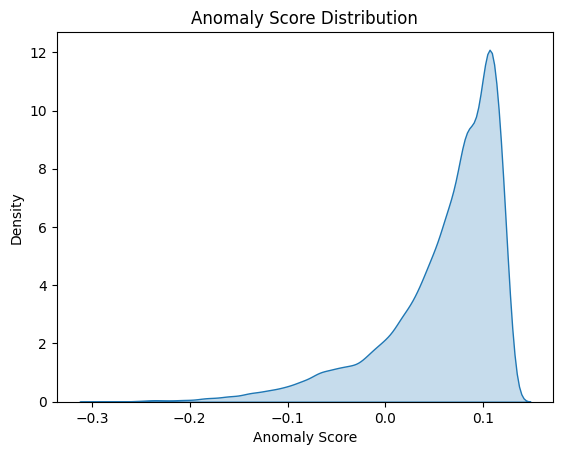

In [ ]:
# Create a density plot
sns.kdeplot(anomaly_scores, fill=True)
plt.xlabel('Anomaly Score')
plt.ylabel('Density')
plt.title('Anomaly Score Distribution')
plt.show()

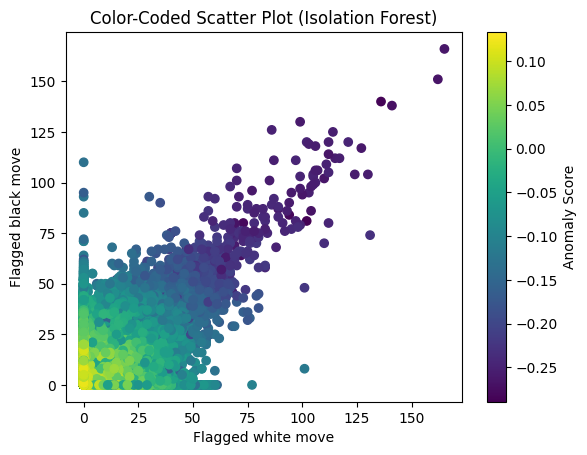

In [ ]:
# Color Coded Scatter Plot
features = ['Flagged white move', 'Flagged black move', 'Elo White', 'Elo Black']
x = df[features]  # Select features for plotting
y = df['result']  # Target variable

# Train the Isolation Forest model
clf = IsolationForest(contamination='auto')
clf.fit(x)

# Get anomaly scores
anomaly_scores = clf.decision_function(x)  # Use decision_function for anomaly scores

# Color-coded scatter plot
plt.scatter(x['Flagged white move'], x['Flagged black move'], c=anomaly_scores, cmap='viridis')
plt.colorbar(label='Anomaly Score')
plt.title('Color-Coded Scatter Plot (Isolation Forest)')
plt.xlabel('Flagged white move')
plt.ylabel('Flagged black move')
plt.show()

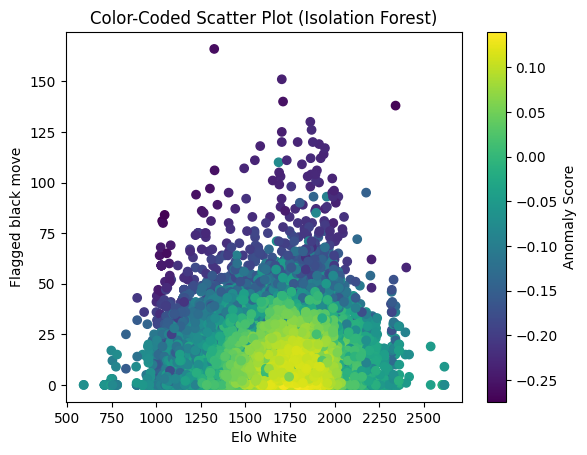

In [ ]:
# Color Coded Scatter Plot
features = ['Flagged white move', 'Flagged black move', 'Elo White', 'Elo Black']
x = df[features]  # Select features for plotting
y = df['result']  # Target variable

# Train the Isolation Forest model
clf = IsolationForest(contamination='auto')
clf.fit(x)

# Get anomaly scores
anomaly_scores = clf.decision_function(x)  # Use decision_function for anomaly scores

# Color-coded scatter plot
plt.scatter(x['Elo White'], x['Flagged black move'], c=anomaly_scores, cmap='viridis')
plt.colorbar(label='Anomaly Score')
plt.title('Color-Coded Scatter Plot (Isolation Forest)')
plt.xlabel('Elo White')
plt.ylabel('Flagged black move')
plt.show()

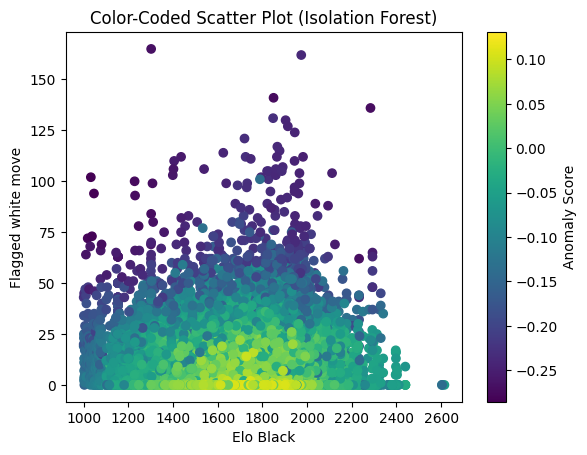

In [ ]:
# Color Coded Scatter Plot

features = ['Flagged white move', 'Flagged black move', 'Elo White', 'Elo Black']
x = df[features]  # Select features for plotting
y = df['result']  # Target variable


clf = IsolationForest(contamination='auto')
clf.fit(x)

# Get anomaly scores
anomaly_scores = clf.decision_function(x)  # Use decision_function for anomaly scores

# Color-coded scatter plot
plt.scatter(x['Elo Black'], x['Flagged white move'], c=anomaly_scores, cmap='viridis')
plt.colorbar(label='Anomaly Score')
plt.title('Color-Coded Scatter Plot (Isolation Forest)')
plt.xlabel('Elo Black')
plt.ylabel('Flagged white move')
plt.show()

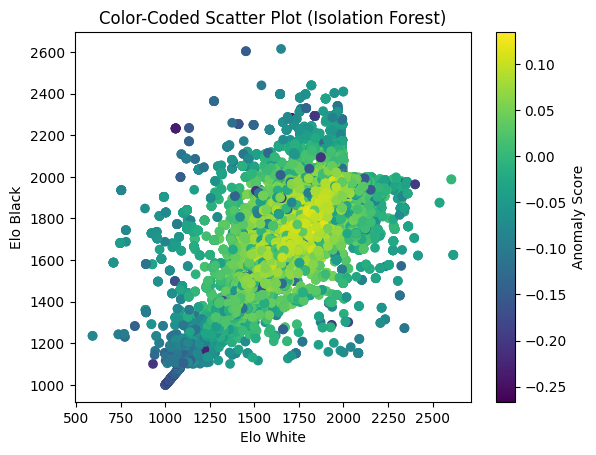

In [ ]:
# Color Coded Scatter Plot

features = ['Flagged white move', 'Flagged black move', 'Elo White', 'Elo Black']
x = df[features]  # Select features for plotting
y = df['result']  # Target variable

# Train the Isolation Forest model
clf = IsolationForest(contamination='auto')
clf.fit(x)

# Get anomaly scores
anomaly_scores = clf.decision_function(x)  # Use decision_function for anomaly scores

# Color-coded scatter plot
plt.scatter(x['Elo White'], x['Elo Black'], c=anomaly_scores, cmap='viridis')
plt.colorbar(label='Anomaly Score')
plt.title('Color-Coded Scatter Plot (Isolation Forest)')
plt.xlabel('Elo White')
plt.ylabel('Elo Black')
plt.show()

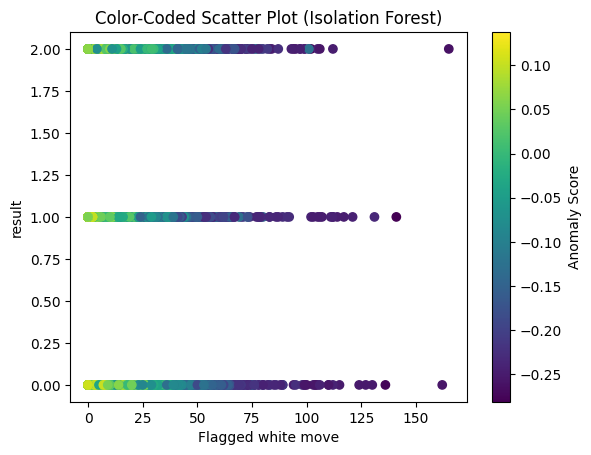

In [ ]:
# Color Coded Scatter Plot

features = ['Flagged white move', 'Flagged black move', 'Elo White', 'Elo Black']
x = df[features]  # Select features for plotting
y = df['result']  # Target variable

# Train the Isolation Forest model
clf = IsolationForest(contamination='auto')
clf.fit(x)

# Get anomaly scores
anomaly_scores = clf.decision_function(x)  # Use decision_function for anomaly scores

# Color-coded scatter plot
plt.scatter(x['Flagged white move'], y, c=anomaly_scores, cmap='viridis')
plt.colorbar(label='Anomaly Score')
plt.title('Color-Coded Scatter Plot (Isolation Forest)')
plt.xlabel('Flagged white move')
plt.ylabel('result')
plt.show()

/usr/local/lib/python3.10/dist-packages/matplotlib/collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


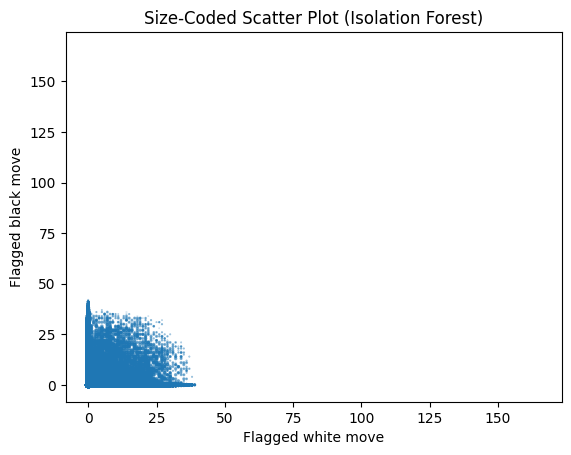

In [ ]:
# Size Coded Scatter Plot

features = ['Flagged white move', 'Flagged black move', 'Elo White', 'Elo Black']
x = df[features]  # Select features for plotting
y = df['result']  # Target variable

# Train the Isolation Forest model
clf = IsolationForest(contamination='auto')
clf.fit(x)

# Get anomaly scores
anomaly_scores = clf.decision_function(x)  # Use decision_function for anomaly scores

# Scale anomaly scores for better visualization (optional)
anomaly_scores = anomaly_scores * 100

# Size-coded scatter plot
plt.scatter(x['Flagged white move'], x['Flagged black move'], s=anomaly_scores, alpha=0.5)
plt.title('Size-Coded Scatter Plot (Isolation Forest)')
plt.xlabel('Flagged white move')
plt.ylabel('Flagged black move')
plt.show()

In [ ]:

features = ['Flagged white move', 'Flagged black move', 'Elo White', 'Elo Black', 'result']

# Select features for plotting and include 'result' if it was used during training
x = df[features]  # Select features for plotting
# If 'result' was used during training, include it here:
# x = df[features + ['result']]

# Train the Isolation Forest model (assuming it's already defined)
# Ensure you are training the model with the correct features
clf = IsolationForest(contamination='auto')
clf.fit(x)

# Get anomaly scores
anomaly_scores = clf.decision_function(x)


Feature ranking:
1. feature 0 (0.533676)
2. feature 2 (0.418310)
3. feature 1 (0.399428)
4. feature 3 (0.396177)
5. feature 4 (0.232029)


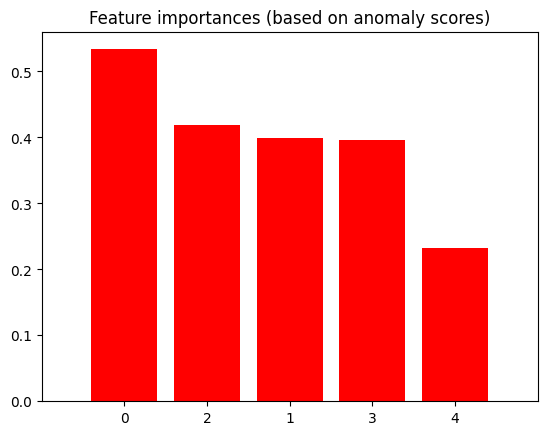

In [ ]:
# Get anomaly scores
anomaly_scores = clf.decision_function(x)

# Analyze anomaly scores for each feature (e.g., using correlation)
feature_importance = np.abs(np.corrcoef(anomaly_scores, x, rowvar=False)[0, 1:])

# Sort feature importance in descending order
indices = np.argsort(feature_importance)[::-1]

# Print the feature ranking
print("Feature ranking:")
for f in range(x.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], feature_importance[indices[f]]))

# Plot the feature importances
plt.figure()
plt.title("Feature importances (based on anomaly scores)")
plt.bar(range(x.shape[1]), feature_importance[indices],
       color="r", align="center")
plt.xticks(range(x.shape[1]), indices)
plt.xlim([-1, x.shape[1]])
plt.show()

In [ ]:
# Define an anomaly threshold
threshold = -0.1

anomalies = df[anomaly_scores > threshold]

print("Number of Potential Anomalies:", len(anomalies))

Number of Potential Anomalies: 46677


In [ ]:
kmeans = KMeans(n_clusters=2, init='k-means++', n_init='auto', max_iter=300, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='elkan')
kmeans.fit(df)
labels = kmeans.labels_

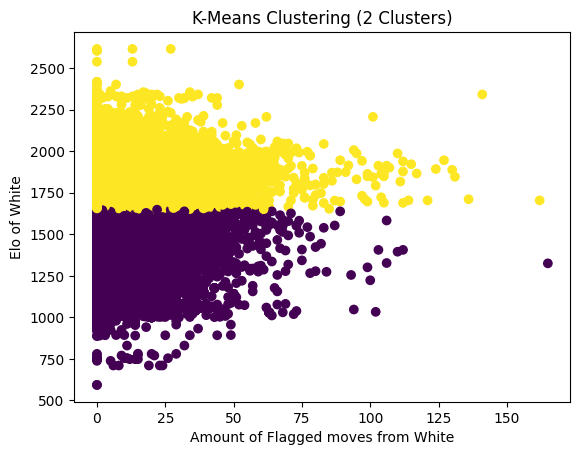

In [ ]:


# Extract the features you want to plot
features = df.iloc[:, [0, 2]]

# Fit the KMeans model
kmeans.fit(features)

# Get the cluster labels assigned by KMeans
labels = kmeans.labels_

# Plot the data points with different colors based on their cluster labels
plt.scatter(features.iloc[:, 0], features.iloc[:, 1], c=labels, cmap='viridis')

# Add labels and title to the plot
plt.xlabel('Amount of Flagged moves from White')
plt.ylabel('Elo of White')
plt.title('K-Means Clustering (2 Clusters)')

# Show the plot
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=2, init='k-means++', n_init='auto', max_iter=300, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='lloyd')
kmeans.fit(df)
labels = kmeans.labels_

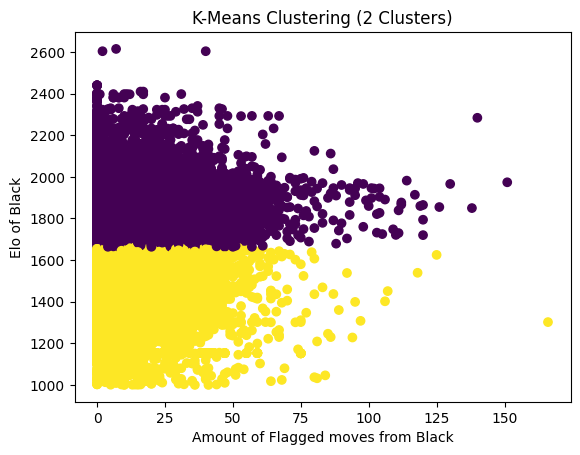

In [ ]:

features = df.iloc[:, [1, 3]]

# Fit the KMeans model
kmeans.fit(features)

# Get the cluster labels assigned by KMeans
labels = kmeans.labels_

# Plot the data points with different colors based on their cluster labels
plt.scatter(features.iloc[:, 0], features.iloc[:, 1], c=labels, cmap='viridis')

# Add labels and title to the plot
plt.xlabel('Amount of Flagged moves from Black')
plt.ylabel('Elo of Black')
plt.title('K-Means Clustering (2 Clusters)')

# Show the plot
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=2, init='k-means++', n_init='auto', max_iter=300, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='elkan')
kmeans.fit(df)
labels = kmeans.labels_

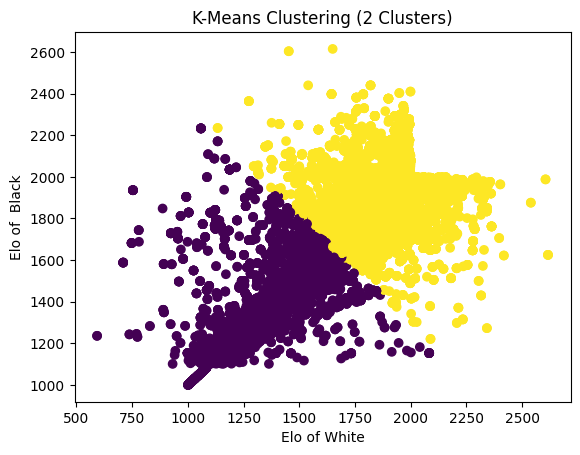

In [ ]:


# Extract the features you want to plot (assuming first two columns)
features = df.iloc[:, [2, 3]]

# Fit the KMeans model (assuming you already have it defined)
kmeans.fit(features)

# Get the cluster labels assigned by KMeans
labels = kmeans.labels_

# Plot the data points with different colors based on their cluster labels
plt.scatter(features.iloc[:, 0], features.iloc[:, 1], c=labels, cmap='viridis')

# Add labels and title to the plot
plt.xlabel('Elo of White')
plt.ylabel('Elo of  Black')
plt.title('K-Means Clustering (2 Clusters)')

# Show the plot
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=2, init='k-means++', n_init='auto', max_iter=300, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='lloyd')
kmeans.fit(df)
labels = kmeans.labels_

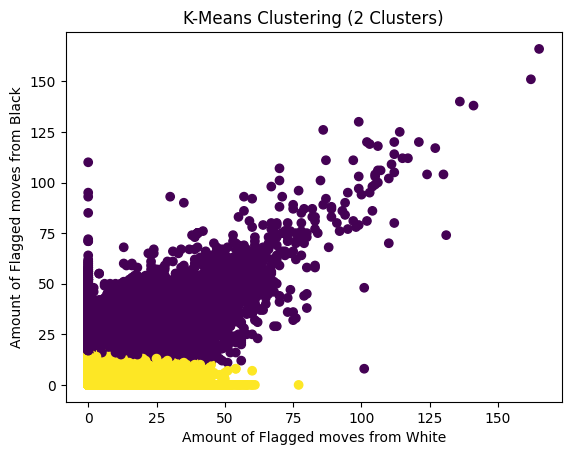

In [ ]:


# Extract the features you want to plot

# Fit the KMeans model
kmeans.fit(features)

# Get the cluster labels assigned by KMeans
labels = kmeans.labels_

# Plot the data points with different colors based on their cluster labels
plt.scatter(features.iloc[:, 0], features.iloc[:, 1], c=labels, cmap='viridis')

# Add labels and title to the plot
plt.xlabel('Amount of Flagged moves from White')
plt.ylabel('Amount of Flagged moves from Black')
plt.title('K-Means Clustering (2 Clusters)')

# Show the plot
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=2, init='k-means++', n_init='auto', max_iter=300, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='elkan')
kmeans.fit(df)
labels = kmeans.labels_

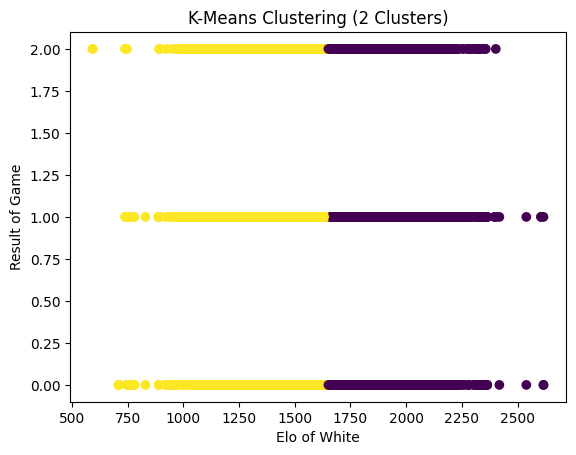

In [ ]:


# Extract the features you want to plot
features = df.iloc[:, [2, 4]]

# Fit the KMeans model
kmeans.fit(features)

# Get the cluster labels assigned by KMeans
labels = kmeans.labels_

# Plot the data points with different colors based on their cluster labels
plt.scatter(features.iloc[:, 0], features.iloc[:, 1], c=labels, cmap='viridis')

# Add labels and title to the plot
plt.xlabel('Elo of White')
plt.ylabel('Result of Game')
plt.title('K-Means Clustering (2 Clusters)')

# Show the plot
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=2, init='k-means++', n_init='auto', max_iter=300, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='elkan')
kmeans.fit(df)
labels = kmeans.labels_

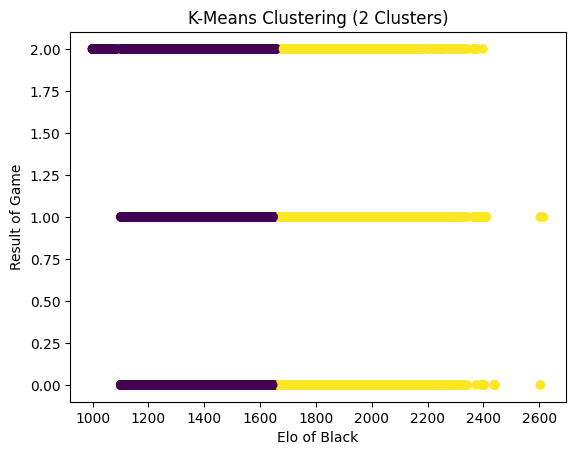

In [ ]:


# Extract the features you want to plot
features = df.iloc[:, [3, 4]]

# Fit the KMeans model
kmeans.fit(features)

# Get the cluster labels assigned by KMeans
labels = kmeans.labels_

# Plot the data points with different colors based on their cluster labels
plt.scatter(features.iloc[:, 0], features.iloc[:, 1], c=labels, cmap='viridis')

# Add labels and title to the plot
plt.xlabel('Elo of Black')
plt.ylabel('Result of Game')
plt.title('K-Means Clustering (2 Clusters)')

# Show the plot
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=2, init='k-means++', n_init='auto', max_iter=300, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='elkan')
kmeans.fit(df)
labels = kmeans.labels_

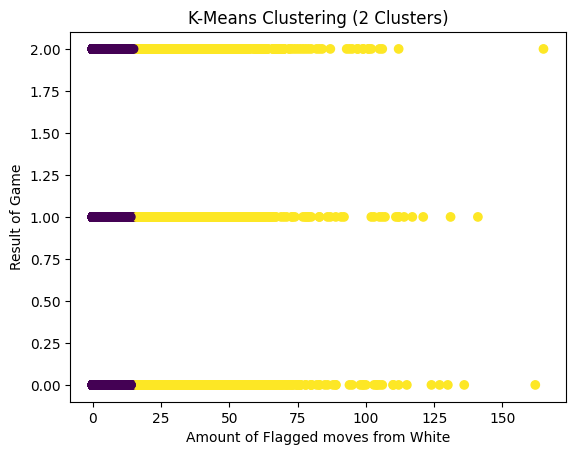

In [ ]:


# Extract the features you want to plot
features = df.iloc[:, [0, 4]]

# Fit the KMeans model
kmeans.fit(features)

# Get the cluster labels assigned by KMeans
labels = kmeans.labels_

# Plot the data points with different colors based on their cluster labels
plt.scatter(features.iloc[:, 0], features.iloc[:, 1], c=labels, cmap='viridis')

# Add labels and title to the plot
plt.xlabel('Amount of Flagged moves from White')
plt.ylabel('Result of Game')
plt.title('K-Means Clustering (2 Clusters)')

# Show the plot
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=2, init='k-means++', n_init='auto', max_iter=300, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='elkan')
kmeans.fit(df)
labels = kmeans.labels_

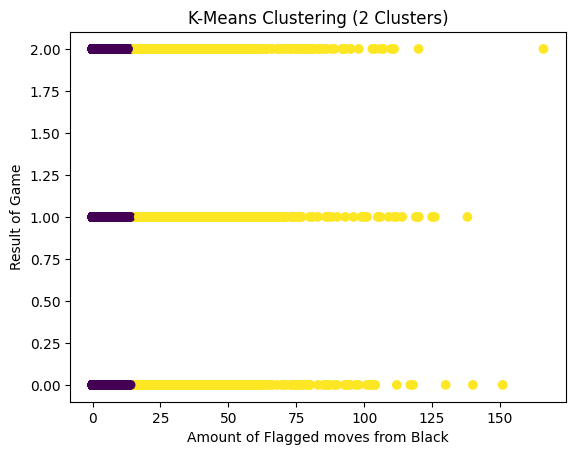

In [ ]:


# Extract the features you want to plot
features = df.iloc[:, [1, 4]]

# Fit the KMeans model
kmeans.fit(features)

# Get the cluster labels assigned by KMeans
labels = kmeans.labels_

# Plot the data points with different colors based on their cluster labels
plt.scatter(features.iloc[:, 0], features.iloc[:, 1], c=labels, cmap='viridis')

# Add labels and title to the plot
plt.xlabel('Amount of Flagged moves from Black')
plt.ylabel('Result of Game')
plt.title('K-Means Clustering (2 Clusters)')

# Show the plot
plt.show()